# Mapping U\.S\. Office Markets That Support Agile, Post\-Pandemic Work Models

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import plotly.io as pio

In [3]:
lease = pd.read_csv("Leases.csv") 
price_availability_df = pd.read_csv("Price and Availability Data.csv")
occupancy_df = pd.read_csv("Major Market Occupancy Data-revised-20250412-051645.csv")

## 1\. Tech industry presence \(just for doc purpose\)

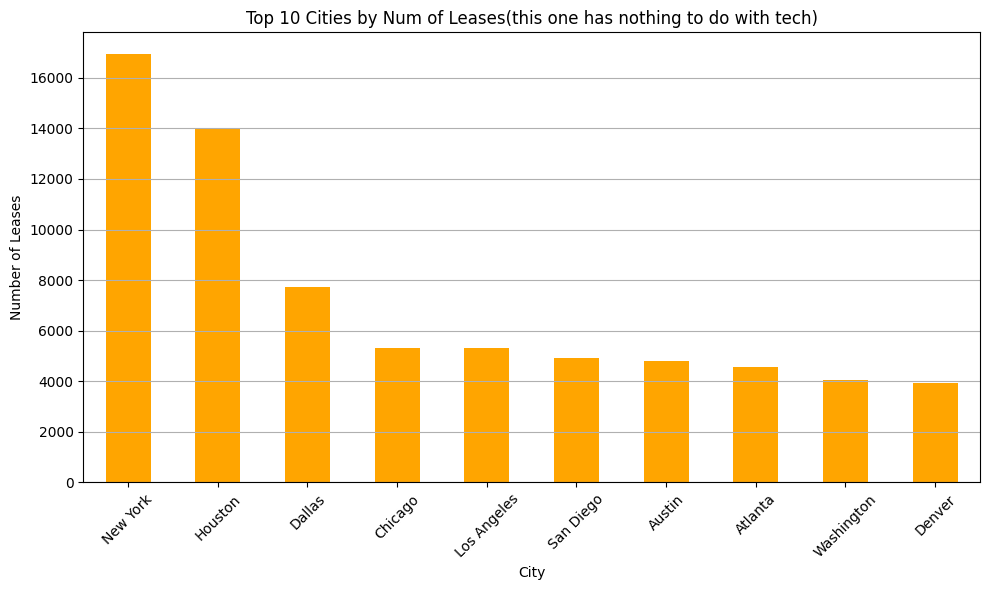

In [14]:
top_10_cities = lease['city'].value_counts().head(10)


plt.figure(figsize=(10, 6))
top_10_cities.plot(kind='bar', color='orange')
plt.title('Top 10 Cities by Num of Leases(this one has nothing to do with tech)')
plt.xlabel('City')
plt.ylabel('Number of Leases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [5]:
industry = lease[['city', 'state', 'internal_industry', 'leasedSF']]

industry = industry.dropna(subset=['internal_industry', 'city', 'state'])

industry.head(4)


,city,state,internal_industry,leasedSF
0,Atlanta,GA,Financial Services and Insurance,24736.0
6,Peachtree Corners,GA,"Construction, Engineering and Architecture",13207.0
9,Atlanta,GA,"Technology, Advertising, Media, and Information",15795.0
14,Atlanta,GA,"Technology, Advertising, Media, and Information",49914.0


In [6]:
tech_keywords = ['tech', 'technology', 'software', 'it', 'data', 'digital']
tech = industry[industry['internal_industry'].dropna().str.lower().str.contains('|'.join(tech_keywords))]

# Group by city and state, and sum leased square footage
tech_by_city = tech.groupby(['city', 'state'])['leasedSF'].sum().sort_values(ascending=False)

# Top 15 tech cities by sum leased square footage
print(tech_by_city.head(15))

# next step: consider other factors to normalize it, like space per employeement ratio??

city           state
New York       NY       56569597.0
Houston        TX       18507703.0
San Francisco  CA       13889354.0
Chicago        IL       13760146.0
Washington     DC       11370375.0
Austin         TX        9655554.0
Atlanta        GA        8539069.0
Bellevue       WA        7282528.0
Los Angeles    CA        6528754.0
San Jose       CA        5903466.0
Seattle        WA        5102247.0
Arlington      VA        5051292.0
Denver         CO        4843703.0
Boston         MA        4617372.0
San Diego      CA        4465272.0
Name: leasedSF, dtype: float64


## 2\. Map of Top Flexible Office Markets

In a post-covid world, we want to identify U.S. office markets in the tech industry that are most suited to hybrid work and flexible leasing, using internal leasing, pricing, and occupancy data. (Are we still looking into external data like walkability or transit accesibility? Edwin?)

Question: Consider focusing on a specific indsutry? Or not? 

Key metrics: 

sublet_availability_proportion: 
avg_occupancy_proportion(not using it anymore)
overall_rent
availability_proportion

In [7]:
sublet_grouped = lease.groupby("market", as_index=False)["sublet_availability_proportion"].mean()
occupancy_grouped = occupancy_df.groupby("market", as_index=False)["avg_occupancy_proportion"].mean()
price_grouped = price_availability_df.groupby("market", as_index=False)[
    ["availability_proportion", "overall_rent"]
].mean()

# Merge all data
merged_df = price_grouped.merge(sublet_grouped, on="market", how="left")
merged_df = merged_df.merge(occupancy_grouped, on="market", how="left")
merged_df.dropna(inplace=True)

# Normalize + score
scaler = MinMaxScaler()
scaled = scaler.fit_transform(merged_df[[
    "availability_proportion",
    "sublet_availability_proportion",
    "overall_rent",
    "avg_occupancy_proportion"
]])
scaled[:, 2] = 1 - scaled[:, 2]  # invert rent

weights = np.array([0.25, 0.25, 0.25, 0.25])
merged_df["flexible_office_score"] = np.dot(scaled, weights)

# Save as score_df
score_df = merged_df.sort_values(by="flexible_office_score", ascending=False)
score_df

,market,availability_proportion,overall_rent,sublet_availability_proportion,avg_occupancy_proportion,flexible_office_score
10,Houston,0.278232,29.613804,0.012351,0.503773,0.733365
1,Austin,0.191850,42.048777,0.020958,0.517043,0.591587
11,Los Angeles,0.224983,44.143134,0.020408,0.398406,0.495216
17,Philadelphia,0.203185,29.693244,0.020014,0.365611,0.480221
22,San Francisco,0.233347,72.441176,0.037522,0.317613,0.433915
12,Manhattan,0.157688,77.627159,0.018063,0.349343,0.096501


In [8]:
# render it
pio.renderers.default = 'notebook_connected'

# Aggregate by market
sublet_grouped = lease.groupby("market", as_index=False)["sublet_availability_proportion"].mean()
occupancy_grouped = occupancy_df.groupby("market", as_index=False)["avg_occupancy_proportion"].mean()
price_grouped = price_availability_df.groupby("market", as_index=False)[
    ["availability_proportion", "overall_rent"]
].mean()

# Merge data
merged_df = price_grouped.merge(sublet_grouped, on="market", how="left")
merged_df = merged_df.merge(occupancy_grouped, on="market", how="left")
print("Missing values:\n", merged_df.isna().sum())
print("Rows before cleaning:", merged_df.shape[0])

# Drop rows with missing critical data
merged_df.dropna(subset=[
    "availability_proportion",
    "sublet_availability_proportion",
    "overall_rent",
    "avg_occupancy_proportion"
], inplace=True)
print("Rows after cleaning:", merged_df.shape[0])

# Scale and score
scaler = MinMaxScaler()
scaled = scaler.fit_transform(merged_df[[
    "availability_proportion",
    "sublet_availability_proportion",
    "overall_rent",
    "avg_occupancy_proportion"
]])
scaled[:, 2] = 1 - scaled[:, 2]  # Invert rent (lower rent is better)

weights = np.array([0.25, 0.25, 0.25, 0.25])
merged_df["flexible_office_score"] = np.dot(scaled, weights)

# Come up with the score dataset
score_df = merged_df.sort_values(by="flexible_office_score", ascending=False)


Missing values:
 market                             0
availability_proportion            0
overall_rent                       0
sublet_availability_proportion     9
avg_occupancy_proportion          24
dtype: int64
Rows before cleaning: 30
Rows after cleaning: 6


In [9]:
%pip install geopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 19.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 11.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
city = {
    "New York": (40.730610, -73.935242),
    "San Francisco": (37.7749, -122.4194),
    "Chicago": (41.8781, -87.6298),
    "Atlanta": (33.7490, -84.3880),
    "Los Angeles": (34.0522, -118.2437),
    "Boston": (42.3601, -71.0589),
    "Houston": (29.7604, -95.3698),
    "Dallas": (32.7767, -96.7970),
    "Seattle": (47.6062, -122.3321),
    "Denver": (39.7392, -104.9903),
    "Austin": (30.2666, -97.7333),
    "Philadelphia": (39.9525, -75.165222),
    "Manhattan": (40.7766, -73.971321)
}
# from geopy import geocoders
# from geopy.geocoders import Nominatim

# gn = geocoders.GeoNames(username='hyperupcall')
# app = Nominatim(user_agent="tutorial")
# location = app.geocode("Nairobi, Kenya").raw
# print(location)
# def f1(x):
#     print(x)
#     return app.geocode(x).raw.lat

# def f2(x):
#     print(x)
#     return app.geocode(x).raw.lon

score_df1 = score_df.copy()
# score_df1 = merged_df.copy()
# merged_df

score_df1["lat"] = score_df1['market'].map(lambda x: city.get(x, (None, None))[0])
score_df1["lon"]= score_df1["market"].map(lambda x: city.get(x, (None, None))[1])
fig = px.scatter_geo(
    score_df1,
    lat="lat",
    lon="lon",
    # locations='market',
    size="flexible_office_score",
    color="flexible_office_score",
    hover_name="market",
    # projection="albers usa",
    # fitbounds="locations",  # auto-zoom
    title="Top Flexible Office Markets in the U.S.",
    # size_max=25,
    # scope='usa'
    # color_continuous_scale="Viridis"
)
fig.update_layout(geo=dict(scope="usa"))
# # fig.update_traces(marker=dict(size=10, color='red'))

fig.show()

# # Save the map to an HTML file? Can't display here or render 
# # fig.write_html("flexible_office_map.html")


In [11]:
score_df1

,market,availability_proportion,overall_rent,sublet_availability_proportion,avg_occupancy_proportion,flexible_office_score,lat,lon
10,Houston,0.278232,29.613804,0.012351,0.503773,0.733365,29.7604,-95.369800
1,Austin,0.191850,42.048777,0.020958,0.517043,0.591587,30.2666,-97.733300
11,Los Angeles,0.224983,44.143134,0.020408,0.398406,0.495216,34.0522,-118.243700
17,Philadelphia,0.203185,29.693244,0.020014,0.365611,0.480221,39.9525,-75.165222
22,San Francisco,0.233347,72.441176,0.037522,0.317613,0.433915,37.7749,-122.419400
12,Manhattan,0.157688,77.627159,0.018063,0.349343,0.096501,40.7766,-73.971321


In [12]:
lease["market"].unique()

array(['Atlanta', 'Austin', 'Baltimore', 'Boston', 'Charlotte', 'Chicago',
       'Chicago Suburbs', 'Dallas/Ft Worth', 'Denver', 'Detroit',
       'Houston', 'Los Angeles', 'Manhattan', 'Nashville',
       'Northern New Jersey', 'Northern Virginia', 'Orange County',
       'Philadelphia', 'Phoenix', 'Raleigh/Durham', 'Salt Lake City',
       'San Diego', 'San Francisco', 'Seattle', 'South Bay/San Jose',
       'South Florida', 'Southern Maryland', 'Tampa', 'Washington D.C.'],
      dtype=object)

In [12]:

import plotly.express as px
import plotly.io as pio

# Set Plotly renderer
pio.renderers.default = 'notebook_connected'



lease.columns = lease.columns.str.strip().str.lower()
price_availability_df.columns = price_availability_df.columns.str.strip().str.lower()
occupancy_df.columns = occupancy_df.columns.str.strip().str.lower()


tech_leases = lease[lease["internal_industry"].str.contains("technology|it|information", case=False, na=False)]


sublet_grouped_tech = tech_leases.groupby("market", as_index=False)["sublet_availability_proportion"].mean()
price_grouped = price_availability_df.groupby("market", as_index=False)[["availability_proportion", "overall_rent"]].mean()
occupancy_grouped = occupancy_df.groupby("market", as_index=False)["avg_occupancy_proportion"].mean()


merged_df = price_grouped.merge(sublet_grouped_tech, on="market", how="left")
merged_df = merged_df.merge(occupancy_grouped, on="market", how="left")


merged_df.dropna(subset=[
    "availability_proportion", "sublet_availability_proportion", 
    "overall_rent", "avg_occupancy_proportion"
], inplace=True)


scaler = MinMaxScaler()
scaled = scaler.fit_transform(merged_df[[
    "availability_proportion",
    "sublet_availability_proportion",
    "overall_rent",
    "avg_occupancy_proportion"
]])
scaled[:, 2] = 1 - scaled[:, 2]  # invert rent

weights = np.array([0.25, 0.25, 0.25, 0.25])
merged_df["tech_flexible_office_score"] = np.dot(scaled, weights)


score_df_tech = merged_df.sort_values(by="tech_flexible_office_score", ascending=False)




In [ ]:
score_df_tech.head(5)

In [12]:
# Add city coordinates
city_coords = {
    "Houston": (29.7604, -95.3698),
    "Austin": (30.2672, -97.7431),
    "Los Angeles": (34.0522, -118.2437),
    "San Francisco": (37.7749, -122.4194),
    "Philadelphia": (39.9526, -75.1652),
    
}
score_df_tech["lat"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[0])
score_df_tech["lon"] = score_df_tech["market"].map(lambda x: city_coords.get(x, (None, None))[1])
score_df_tech.dropna(subset=["lat", "lon"], inplace=True)

fig = px.scatter_geo(
    score_df_tech.head(15),
    lat="lat",
    lon="lon",
    size="tech_flexible_office_score",
    color="tech_flexible_office_score",
    hover_name="market",
    projection="albers usa",
    title="Top U.S. Office Markets for Tech Sector Flexibility",
    size_max=25,
    color_continuous_scale="Viridis"
)

fig.update_layout(geo=dict(scope="usa"))
fig.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4487cead-9e45-4286-b5b8-37614f9dfcb9' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>